In [ ]:
import os
import shutil
from google.colab import drive

# 1. CÀI ĐẶT THƯ VIỆN CẦN THIẾT
!pip install editdistance
!apt-get install unrar > /dev/null

# 2. MOUNT DRIVE (Để lưu model)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
from google.colab import drive

# 1. CÀI ĐẶT THƯ VIỆN CẦN THIẾT
!pip install editdistance
!apt-get install unrar > /dev/null

# 2. MOUNT DRIVE (Để lưu model)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

CKPT_SAVE_PATH = "/content/drive/MyDrive/starnet_best.pth"
print(f"--> Checkpoint sẽ được lưu tại: {CKPT_SAVE_PATH}")

# 3. GIẢI NÉN DỮ LIỆU (Train/Valid/Test)
# Cấu hình tên file đã upload
rar_files = {
    "train": "train.rar",
    "valid": "valid.rar",
    "test":  "test.rar"
}

for mode, filename in rar_files.items():
    rar_path = f"/content/{filename}"
    extract_to = f"/content/{mode}" # VD: /content/train

    if os.path.exists(rar_path):
        if not os.path.exists(extract_to):
            os.makedirs(extract_to)
        print(f"Đang giải nén {filename} vào {extract_to}...")

        # Lệnh giải nén (x: extract, -inul: im lặng, -o+: ghi đè)
        # Thêm dấu "" quanh đường dẫn để tránh lỗi nếu tên file có khoảng trắng
        !unrar x -inul -o+ "{rar_path}" "{extract_to}"

        # --- ĐOẠN CODE ĐẾM FILE ---
        total_files = 0
        for root, dirs, files in os.walk(extract_to):
            total_files += len(files)
        # --------------------------

        print(f"--> Xong {mode}! Tổng số file đã giải nén: {total_files}")
    else:
        print(f"[Cảnh báo] Không tìm thấy file {filename}. Hãy upload lên Colab!")

--> Checkpoint sẽ được lưu tại: /content/drive/MyDrive/starnet_best.pth
Đang giải nén train.rar vào /content/train...
--> Xong train! Tổng số file đã giải nén: 330961
Đang giải nén valid.rar vào /content/valid...
--> Xong valid! Tổng số file đã giải nén: 41370
Đang giải nén test.rar vào /content/test...
--> Xong test! Tổng số file đã giải nén: 41370


In [ ]:
import pandas as pd

# Tên file CSV gốc bạn upload
csv_files = {
    "train": "written_name_train.csv",
    "valid": "written_name_valid.csv",
    "test":  "written_name_test.csv"
}

# 1. TẠO DATASET TRAIN RÚT GỌN (120k mẫu)
if os.path.exists(csv_files["train"]):
    print("Đang xử lý Train CSV...")
    df = pd.read_csv(csv_files["train"])
    # Lấy 120k mẫu ngẫu nhiên
    SAMPLE_SIZE = 120000
    if len(df) > SAMPLE_SIZE:
        df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
    df.to_csv("train_mini.csv", index=False)
    print(f"--> Đã tạo 'train_mini.csv' ({len(df)} dòng)")

# 2. TẠO DATASET VALID RÚT GỌN (5k mẫu)
if os.path.exists(csv_files["valid"]):
    print("Đang xử lý Valid CSV...")
    df = pd.read_csv(csv_files["valid"])
    VALID_SIZE = 5000
    if len(df) > VALID_SIZE:
        df = df.sample(n=VALID_SIZE, random_state=42).reset_index(drop=True)
    df.to_csv("valid_mini.csv", index=False)
    print(f"--> Đã tạo 'valid_mini.csv' ({len(df)} dòng)")

# 3. XỬ LÝ DATASET TEST (LỌC RÁC)
if os.path.exists(csv_files["test"]):
    print("Đang xử lý Test CSV...")
    df = pd.read_csv(csv_files["test"])
    # Lọc bỏ UNREADABLE và NaN
    df = df[df['IDENTITY'] != 'UNREADABLE']
    df = df.dropna(subset=['IDENTITY', 'FILENAME'])
    # Sửa tên file: bỏ đường dẫn thừa nếu có (VD: test/img.jpg -> img.jpg)
    df['FILENAME'] = df['FILENAME'].apply(lambda x: os.path.basename(x))

    df.to_csv("test_clean.csv", index=False)
    print(f"--> Đã tạo 'test_clean.csv' ({len(df)} dòng sạch)")

Đang xử lý Train CSV...
--> Đã tạo 'train_mini.csv' (120000 dòng)
Đang xử lý Valid CSV...
--> Đã tạo 'valid_mini.csv' (5000 dòng)
Đang xử lý Test CSV...
--> Đã tạo 'test_clean.csv' (41289 dòng sạch)


In [ ]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

# --- CONFIG ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# STAR-Net thường dùng ảnh đầu vào lớn hơn chút để TPS có không gian nắn
IMG_H = 32
IMG_W = 128
BATCH_SIZE = 64
EPOCHS = 30
LR = 1e-3
MAX_LEN = 32

CHARS = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789: "
BLANK_IDX = 0
# Map ký tự: 0 dành cho Blank (CTC), ký tự thực bắt đầu từ 1
char2idx = {c: i + 1 for i, c in enumerate(CHARS)}
idx2char = {i + 1: c for i, c in enumerate(CHARS)}
NUM_CLASSES = len(CHARS) + 1

# --- HÀM TÌM ẢNH ---
def find_image_folder(base_path):
    if not os.path.exists(base_path): return base_path
    for root, dirs, files in os.walk(base_path):
        if any(f.lower().endswith(('.jpg', '.png')) for f in files):
            if sum(1 for f in files if f.lower().endswith(('.jpg', '.png'))) > 5:
                return root
    return base_path

# --- DATASET & PREPROCESSING ---
class OCRDataset(Dataset):
    def __init__(self, csv_file, img_dir, mode='train'):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.mode = mode

        # Transform cơ bản
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def encode(self, text):
        text = str(text)
        seq = [char2idx[c] for c in text if c in char2idx]
        return torch.tensor(seq, dtype=torch.long)

    def crop_to_content(self, img):
        # Đảo ngược màu để tìm vùng chứa chữ (giả sử nền trắng chữ đen)
        img_inv = 255 - img
        # Tìm các điểm ảnh khác 0
        coords = cv2.findNonZero(img_inv)
        if coords is not None:
            x, y, w, h = cv2.boundingRect(coords)
            # Cắt vùng chứa nội dung
            crop = img[y:y+h, x:x+w]
            # Nếu ảnh sau khi crop quá nhỏ (nhiễu), giữ nguyên ảnh gốc
            if crop.shape[0] > 0 and crop.shape[1] > 0:
                return crop
        return img

    def resize_padding(self, img, target_h=32, target_w=128):
        h, w = img.shape
        scale = min(target_h / h, target_w / w)
        new_w = int(w * scale); new_h = int(h * scale)
        img_resized = cv2.resize(img, (new_w, new_h))
        padded = np.full((target_h, target_w), 255, dtype=np.uint8)
        padded[:new_h, :new_w] = img_resized
        return padded

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["FILENAME"])

        # Đọc ảnh grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((IMG_H, IMG_W), dtype=np.uint8)

        # Binarize để làm sạch nhiễu nền
        try:
            _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        except: pass

        # 1. Cắt sát nội dung chữ
        img = self.crop_to_content(img)

        # 2. Resize và Padding về kích thước cố định
        img = self.resize_padding(img, IMG_H, IMG_W)

        # 3. Transform (Tensor + Normalize)
        img = self.transform(img)

        label = self.encode(row["IDENTITY"])
        return img, label

    def __len__(self): return len(self.df)

def collate_fn(batch):
    imgs, labels = zip(*batch)
    imgs = torch.stack(imgs)
    # CTC Loss cần target là 1 chuỗi dài nối tiếp và độ dài từng target
    target_lengths = torch.tensor([len(l) for l in labels], dtype=torch.long)
    targets = torch.cat(labels)
    return imgs, targets, target_lengths

# --- LOAD DATA ---
real_train_dir = find_image_folder("/content/train")
real_valid_dir = find_image_folder("/content/valid")

if os.path.exists("train_mini.csv"):
    train_ds = OCRDataset("train_mini.csv", real_train_dir, mode='train')
    train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=2)
    print("Train Loader Ready.")

if os.path.exists("valid_mini.csv"):
    valid_ds = OCRDataset("valid_mini.csv", real_valid_dir, mode='valid')
    valid_loader = DataLoader(valid_ds, BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2)
    print("Valid Loader Ready.")

Train Loader Ready.
Valid Loader Ready.


In [ ]:
# --- CÁC MODULE CON CỦA STAR-NET ---

class LocalizationNetwork(nn.Module):
    def __init__(self, F, I_channel_num):
        super(LocalizationNetwork, self).__init__()
        self.F = F
        self.I_channel_num = I_channel_num
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=self.I_channel_num, out_channels=64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2, 2), # 32x100 -> 16x50
            nn.Conv2d(64, 128, 3, 1, 1, bias=False), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2, 2), # -> 8x25
            nn.Conv2d(128, 256, 3, 1, 1, bias=False), nn.BatchNorm2d(256), nn.ReLU(True), nn.MaxPool2d(2, 2), # -> 4x12
            nn.Conv2d(256, 512, 3, 1, 1, bias=False), nn.BatchNorm2d(512), nn.ReLU(True),
            nn.AdaptiveAvgPool2d(1) # Global pooling
        )
        self.localization_fc2 = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(True),
            nn.Linear(256, self.F * 2) # Output K toạ độ (x, y)
        )
        # Init weights identity
        self.localization_fc2[2].weight.data.fill_(0)
        ctrl_pts_x = np.linspace(-1.0, 1.0, int(F / 2))
        ctrl_pts_y_top = np.linspace(0.0, 0.0, num=int(F / 2))
        ctrl_pts_y_bottom = np.linspace(1.0, 1.0, num=int(F / 2))
        ctrl_pts_top = np.stack([ctrl_pts_x, ctrl_pts_y_top], axis=1)
        ctrl_pts_bottom = np.stack([ctrl_pts_x, ctrl_pts_y_bottom], axis=1)
        initial_bias = np.concatenate([ctrl_pts_top, ctrl_pts_bottom], axis=0)
        self.localization_fc2[2].bias.data = torch.from_numpy(initial_bias).float().view(-1)

    def forward(self, batch_I):
        batch_size = batch_I.size(0)
        features = self.conv(batch_I).view(batch_size, -1)
        batch_C_prime = self.localization_fc2(features).view(batch_size, self.F, 2)
        return batch_C_prime

class GridGenerator(nn.Module):
    def __init__(self, F, I_r_size):
        super(GridGenerator, self).__init__()
        self.F = F
        self.I_r_height, self.I_r_width = I_r_size
        self._build_inv_delta_C(F, I_r_size)

    def _build_inv_delta_C(self, F, I_r_size):
        # 1. Tạo toạ độ điểm điều khiển đích (C)
        ctrl_pts_x = np.linspace(-1.0, 1.0, int(F / 2))
        ctrl_pts_y_top = np.linspace(0.0, 0.0, num=int(F / 2))
        ctrl_pts_y_bottom = np.linspace(1.0, 1.0, num=int(F / 2))
        ctrl_pts_top = np.stack([ctrl_pts_x, ctrl_pts_y_top], axis=1)
        ctrl_pts_bottom = np.stack([ctrl_pts_x, ctrl_pts_y_bottom], axis=1)
        C = np.concatenate([ctrl_pts_top, ctrl_pts_bottom], axis=0)
        C = torch.tensor(C, dtype=torch.float)

        # 2. Xây dựng ma trận L kích thước (N+3, N+3)
        # L = [ K   P ]
        #     [ P^T 0 ]
        N = F
        L = torch.zeros(N + 3, N + 3)

        # Tạo ma trận P: [1, x, y] kích thước (N, 3)
        P = torch.cat([torch.ones(N, 1), C], dim=1) # (N, 3)

        # Điền P vào L
        L[:N, N:] = P
        L[N:, :N] = P.t()

        # Tính ma trận K (RBF Kernel) kích thước (N, N)
        # K_ij = r^2 * log(r)
        dist = torch.cdist(C, C) # Tính khoảng cách giữa các cặp điểm C
        K = (dist ** 2) * torch.log(dist + 1e-6) # Thêm epsilon để tránh log(0)

        # Điền K vào L
        L[:N, :N] = K

        # 3. Tính nghịch đảo của L
        try:
            inv_delta_C = torch.inverse(L)
        except RuntimeError:
            # Nếu ma trận không nghịch đảo được (singular), thêm nhiễu nhỏ vào đường chéo
            print("Warning: TPS matrix is singular, adding epsilon.")
            inv_delta_C = torch.inverse(L + torch.eye(N + 3) * 1e-4)

        self.register_buffer('inv_delta_C', inv_delta_C)
        self.register_buffer('C', C)

        # 4. Chuẩn bị lưới toạ độ P cho ảnh đầu ra (dùng cho forward)
        r_grid_x = (np.arange(-self.I_r_width, self.I_r_width, 2) + 1.0) / self.I_r_width
        r_grid_y = (np.arange(-self.I_r_height, self.I_r_height, 2) + 1.0) / self.I_r_height
        P_grid = np.stack(np.meshgrid(r_grid_x, r_grid_y), axis=2)
        P_grid = torch.tensor(P_grid, dtype=torch.float).view(-1, 2) # (H*W, 2)

        # Mở rộng P_grid để tính RBF với C
        N_grid = P_grid.size(0)
        hat_P = torch.zeros(N_grid, N + 3)

        # Phần [1, x, y] của hat_P
        hat_P[:, N:] = torch.cat([torch.ones(N_grid, 1), P_grid], dim=1)

        # Phần khoảng cách RBF của hat_P
        dist_grid = torch.cdist(P_grid, C) # (N_grid, N)
        hat_P[:, :N] = (dist_grid ** 2) * torch.log(dist_grid + 1e-6)

        self.register_buffer('hat_P', hat_P)

    def forward(self, batch_C_prime):
        B = batch_C_prime.size(0)
        # C_prime mở rộng thêm 3 hàng 0 (cho phần affine) để nhân với inv_delta_C
        batch_C_prime_with_zeros = torch.cat([batch_C_prime, torch.zeros(B, 3, 2, device=batch_C_prime.device)], dim=1)

        # Tính trọng số T = inv_delta_C * C_prime
        batch_T = torch.matmul(self.inv_delta_C, batch_C_prime_with_zeros) # (B, N+3, 2)

        # Tính toạ độ lưới mới P_prime = hat_P * T
        batch_P_prime = torch.matmul(self.hat_P, batch_T) # (B, H*W, 2)
        return batch_P_prime

class TPS_SpatialTransformerNetwork(nn.Module):
    def __init__(self, F, I_size, I_r_size, I_channel_num=1):
        super(TPS_SpatialTransformerNetwork, self).__init__()
        self.F = F
        self.I_size = I_size
        self.I_r_size = I_r_size
        self.I_channel_num = I_channel_num
        self.LocalizationNetwork = LocalizationNetwork(self.F, self.I_channel_num)
        self.GridGenerator = GridGenerator(self.F, self.I_r_size)

    def forward(self, batch_I):
        batch_C_prime = self.LocalizationNetwork(batch_I)
        build_P_prime = self.GridGenerator(batch_C_prime)
        build_P_prime_reshape = build_P_prime.reshape([build_P_prime.size(0), self.I_r_size[0], self.I_r_size[1], 2])

        if torch.__version__ > "1.2.0":
            batch_I_r = F.grid_sample(batch_I, build_P_prime_reshape, padding_mode='border', align_corners=True)
        else:
            batch_I_r = F.grid_sample(batch_I, build_P_prime_reshape, padding_mode='border')
        return batch_I_r

In [ ]:
# --- RESNET BACKBONE & MAIN MODEL ---

class ResNetFeatureExtractor(nn.Module):
    def __init__(self, input_channel=1, output_channel=512):
        super().__init__()
        self.conv0 = nn.Conv2d(input_channel, 64, 3, 1, 1, bias=False)
        self.bn0 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(True)
        self.maxpool = nn.MaxPool2d(2, 2)
        self.layer1 = self._make_layer(64, 128, 2)
        self.layer2 = self._make_layer(128, 256, 2)
        self.layer3 = self._make_layer(256, output_channel, 2)
        self.conv_final = nn.Conv2d(output_channel, output_channel, 2, 1, 0)
        self.bn_final = nn.BatchNorm2d(output_channel)

    def _make_layer(self, in_c, out_c, blocks):
        layers = []
        layers.append(nn.Conv2d(in_c, out_c, 3, 1, 1, bias=False))
        layers.append(nn.BatchNorm2d(out_c))
        layers.append(nn.ReLU(True))
        layers.append(nn.MaxPool2d(2, 2))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv0(x)
        x = self.bn0(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.conv_final(x)
        x = self.bn_final(x)
        x = self.relu(x)
        return x

class STAR_Net(nn.Module):
    def __init__(self, num_classes, hidden_size=256):
        super(STAR_Net, self).__init__()
        # 1. TPS: Nắn ảnh
        self.tps = TPS_SpatialTransformerNetwork(
            F=20, I_size=(IMG_H, IMG_W), I_r_size=(IMG_H, IMG_W), I_channel_num=1
        )

        # 2. ResNet: Trích xuất đặc trưng
        self.feature_extraction = ResNetFeatureExtractor(output_channel=512)

        # 3. BiLSTM: Học chuỗi
        self.rnn = nn.LSTM(512, hidden_size, num_layers=2, batch_first=True, bidirectional=True)

        # 4. FC: Dự đoán
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # x: (B, 1, 32, 100)
        x = self.tps(x)
        x = self.feature_extraction(x)

        # (B, C, H, W) -> (B, W, C)
        x = x.squeeze(2)
        x = x.permute(0, 2, 1)

        self.rnn.flatten_parameters()
        x, _ = self.rnn(x)
        x = self.fc(x)
        return x

model = STAR_Net(num_classes=NUM_CLASSES).to(DEVICE)
print("STAR-Net initialized.")

STAR-Net initialized.


In [ ]:
import torch.optim as optim

criterion = nn.CTCLoss(blank=BLANK_IDX, zero_infinity=True)
optimizer = optim.Adam(model.parameters(), lr=LR)

# SỬA LỖI: Xóa tham số verbose=True vì các phiên bản PyTorch mới không còn hỗ trợ
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

def train_one_epoch(model, dataloader):
    model.train()
    total_loss = 0

    # Progress bar
    pbar = tqdm(dataloader, desc="Training")

    for imgs, targets, target_lengths in pbar:
        imgs = imgs.to(DEVICE)
        targets = targets.to(DEVICE)
        target_lengths = target_lengths.to(DEVICE)

        optimizer.zero_grad()

        preds = model(imgs) # Output: (Batch, Time, Classes)

        # CTC Loss yêu cầu LogSoftmax và shape (Time, Batch, Classes)
        log_probs = F.log_softmax(preds, dim=2).permute(1, 0, 2)

        # Tính Input Lengths (Chiều rộng của Feature Map sau khi qua mạng)
        # STAR-Net width sau khi biến đổi thường cố định hoặc phụ thuộc input
        # Với ảnh 32x100 -> ResNet downsample -> Width khoảng 25-26
        batch_size = imgs.size(0)
        input_lengths = torch.full((batch_size,), log_probs.size(0), dtype=torch.long).to(DEVICE)

        loss = criterion(log_probs, targets, input_lengths, target_lengths)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item()

        # Cập nhật loss lên thanh tiến trình
        pbar.set_postfix({'loss': loss.item()})

    return total_loss / len(dataloader)

@torch.no_grad()
def evaluate(model, dataloader):
    model.eval()
    total_loss = 0
    for imgs, targets, target_lengths in dataloader:
        imgs = imgs.to(DEVICE)
        targets = targets.to(DEVICE)
        target_lengths = target_lengths.to(DEVICE)

        preds = model(imgs)
        log_probs = F.log_softmax(preds, dim=2).permute(1, 0, 2)
        input_lengths = torch.full((imgs.size(0),), log_probs.size(0), dtype=torch.long).to(DEVICE)

        loss = criterion(log_probs, targets, input_lengths, target_lengths)
        total_loss += loss.item()
    return total_loss / len(dataloader)

# --- START TRAINING ---
# Định nghĩa đường dẫn lưu trên Drive
# Bạn có thể đổi tên file hoặc folder tuỳ ý (Ví dụ: /content/drive/MyDrive/OCR_Models/starnet_best.pth)
SAVE_PATH = "/content/drive/MyDrive/starnet_best.pth"

best_val_loss = float('inf')

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_loss = evaluate(model, valid_loader)

    # In ra LR hiện tại
    current_lr = optimizer.param_groups[0]['lr']

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | LR: {current_lr:.6f} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        # --- SỬA Ở ĐÂY: Lưu vào biến SAVE_PATH đã định nghĩa ở trên ---
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"--> Saved Best Model to Drive: {SAVE_PATH}!")

Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 1/30 | LR: 0.001000 | Train Loss: 1.0508 | Val Loss: 0.6215
--> Saved Best Model to Drive: /content/drive/MyDrive/starnet_best.pth!


Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b4c04b0a520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    Exception ignored in: self._shutdown_workers()
<function _MultiProcessingDataLoaderIter.__del__ at 0x7b4c04b0a520>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
        self._shutdown_workers()if w.is_alive():

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
         if w.is_alive(): 
 ^  ^^ ^^ ^^ ^^^ ^ ^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'^
 ^ ^ ^ ^ ^ ^  ^ ^ ^ ^^^^
  File "/

Epoch 2/30 | LR: 0.001000 | Train Loss: 0.5160 | Val Loss: 0.4265
--> Saved Best Model to Drive: /content/drive/MyDrive/starnet_best.pth!


...

Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 29/30 | LR: 0.000031 | Train Loss: 0.0013 | Val Loss: 0.5771


Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b4c04b0a520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7b4c04b0a520> 
 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
       self._shutdown_workers() 
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
      ^if w.is_alive():^
^ ^ ^^  ^^ ^ ^ ^^^^^^^^^^^^^^^

Epoch 30/30 | LR: 0.000031 | Train Loss: 0.0012 | Val Loss: 0.5817


>>> ĐANG ĐÁNH GIÁ TRÊN TẬP TEST...


  0%|          | 0/646 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b4c04b0a520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b4c04b0a520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


=== KẾT QUẢ ===
Accuracy: 51.76%
CER (Character Error Rate): 0.1979

--- VISUALIZE ---


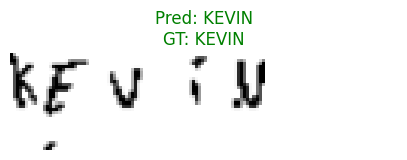

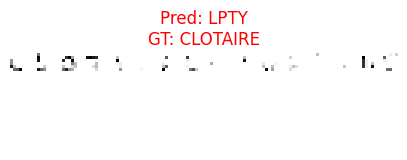

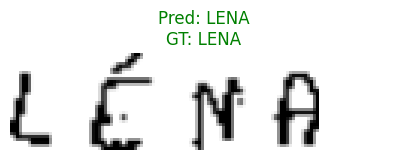

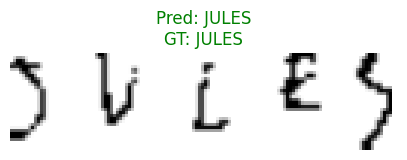

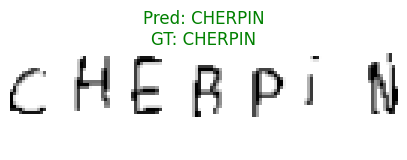

In [ ]:
import editdistance

# Load best model
if os.path.exists("starnet_best.pth"):
    model.load_state_dict(torch.load("starnet_best.pth", map_location=DEVICE))
model.eval()

# Tìm folder test
real_test_dir = find_image_folder("/content/test")
if os.path.exists("test_clean.csv"):
    test_ds = OCRDataset("test_clean.csv", real_test_dir, mode='test')
    test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2)

def ctc_decode(log_probs, idx2char):
    # log_probs: (Batch, Time, Classes) sau khi permute lại hoặc argmax từ model out
    preds_idx = log_probs.argmax(dim=2).detach().cpu().numpy()
    decoded_texts = []

    for seq in preds_idx:
        text = []
        prev_idx = -1
        for idx in seq:
            # Logic CTC: Nếu không phải BLANK và không trùng ký tự trước đó thì lấy
            if idx != BLANK_IDX and idx != prev_idx:
                text.append(idx2char.get(idx, ""))
            prev_idx = idx
        decoded_texts.append("".join(text))
    return decoded_texts

# --- CHẠY ĐÁNH GIÁ ---
correct = 0
total = 0
total_cer = 0
viz_samples = []

print(">>> ĐANG ĐÁNH GIÁ TRÊN TẬP TEST...")
with torch.no_grad():
    for imgs, targets, target_lengths in tqdm(test_loader):
        imgs = imgs.to(DEVICE)

        # Forward
        preds = model(imgs) # (B, T, C)

        # Decode Prediction
        pred_texts = ctc_decode(preds, idx2char)

        # Decode Ground Truth
        # Targets là một chuỗi dài nối tiếp, cần cắt ra dựa trên target_lengths
        start = 0
        target_texts = []
        targets_np = targets.cpu().numpy()
        for length in target_lengths:
            label_seq = targets_np[start : start + length]
            text = "".join([idx2char[i] for i in label_seq])
            target_texts.append(text)
            start += length

        # Tính toán Accuracy & CER
        for i in range(len(pred_texts)):
            p = pred_texts[i]
            g = target_texts[i]

            if p == g: correct += 1
            if len(g) > 0:
                total_cer += editdistance.eval(p, g) / len(g)
            total += 1

            # Lưu vài mẫu để vẽ
            if len(viz_samples) < 5:
                viz_samples.append((imgs[i], p, g))

print(f"\n=== KẾT QUẢ ===")
print(f"Accuracy: {correct/total:.2%}")
print(f"CER (Character Error Rate): {total_cer/total:.4f}")

# Vẽ 5 mẫu ngẫu nhiên
print("\n--- VISUALIZE ---")
for img, p, g in viz_samples:
    img_np = img.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5 # Un-normalize
    plt.figure(figsize=(5, 2))
    plt.imshow(img_np.squeeze(), cmap='gray')
    plt.title(f"Pred: {p}\nGT: {g}", color='green' if p==g else 'red')
    plt.axis('off')
    plt.show()